In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_regression

In [2]:
ds = pd.read_csv('C:/Users/Eric.Niyitanga/Downloads/New York Real Estate Data/new_york_real_estate_2026_final.csv')
ds.head()

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
0,single_family,NaN,No description provided.,325000.0,1252.0,2.0,3.0,2.0,2.0,2.0,1.0
1,single_family,NaN,Shortsale.,308000.0,NaN,NaN,4.0,4.0,4.0,4.0,NaN
2,multi_family,NaN,Discover an exceptional investment opportunity...,799999.0,NaN,NaN,11.0,6.0,7.0,7.0,1.0
3,single_family,NaN,Classic Cape Cod with 4 bedrooms and 2 full ba...,189900.0,1400.0,3.0,4.0,2.0,2.0,2.0,2.0
4,single_family,NaN,"Spacious 4-bedroom, 2.5-bath two-story home of...",204900.0,2074.0,2.0,4.0,2.0,2.0,2.0,2.0


In [3]:
ds.isna().sum()

type                  0
sub_type           6375
text                  0
listPrice             0
sqft               1106
stories            4176
beds                340
baths               391
baths_full          427
baths_full_calc     418
garage             4211
dtype: int64

In [4]:
cleaned_ds = ds.drop(['sub_type','text'], axis=1)
cleaned_ds.describe()

,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
count,8.273000e+03,7.167000e+03,4097.000000,7933.000000,7882.000000,7846.000000,7855.000000,4062.000000
mean,1.094366e+06,2.330063e+03,3.247742,3.439178,2.481604,2.104384,2.117632,2.870261
std,2.542967e+06,1.773651e+04,6.315546,2.058459,1.602000,1.350849,1.353833,30.457501
min,1.000000e+00,1.000000e+00,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,2.500000e+05,1.210000e+03,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000
50%,5.299000e+05,1.680000e+03,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000
75%,9.490000e+05,2.400000e+03,2.000000,4.000000,3.000000,2.000000,2.000000,2.000000
max,8.000000e+07,1.481040e+06,96.000000,100.000000,40.000000,30.000000,30.000000,1440.000000


In [5]:
cleaned_ds.shape

(8273, 9)

In [6]:
cleaned_ds.dtypes

type                object
listPrice          float64
sqft               float64
stories            float64
beds               float64
baths              float64
baths_full         float64
baths_full_calc    float64
garage             float64
dtype: object

In [7]:
cleaned_ds.duplicated().sum()

np.int64(116)

In [8]:
cleaned_ds[cleaned_ds.duplicated()]

,type,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
1919,land,99900.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2376,coop,450000.0,NaN,NaN,0.0,1.0,1.0,1.0,NaN
2396,coop,499000.0,NaN,NaN,0.0,1.0,1.0,1.0,NaN
2516,land,39900.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2636,land,39900.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
8142,land,100000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8157,land,35000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8201,coop,750000.0,NaN,NaN,1.0,1.0,1.0,1.0,NaN
8216,coop,250000.0,550.0,NaN,0.0,1.0,1.0,1.0,NaN


In [9]:
cleaned_ds.isnull().sum()

type                  0
listPrice             0
sqft               1106
stories            4176
beds                340
baths               391
baths_full          427
baths_full_calc     418
garage             4211
dtype: int64

In [10]:
(cleaned_ds.isna().mean()*100).round(2)

type                0.00
listPrice           0.00
sqft               13.37
stories            50.48
beds                4.11
baths               4.73
baths_full          5.16
baths_full_calc     5.05
garage             50.90
dtype: float64

In [12]:
cleaned_ds['sqft'] = cleaned_ds.groupby('type')['sqft'].transform(lambda x: x.fillna(x.median()))

In [13]:

cleaned_ds['beds'] = cleaned_ds.groupby('type')['beds'].transform(lambda x: x.fillna(x.median()))
cleaned_ds['baths'] = cleaned_ds.groupby('type')['baths'].transform(lambda x: x.fillna(x.median()))


In [14]:
cleaned_ds['has_garage'] = cleaned_ds['garage'].notnull().astype(int)
cleaned_ds['garage'] = cleaned_ds['garage'].fillna(0)

In [15]:
cleaned_ds['garage'] = cleaned_ds.groupby('type')['garage'].transform(lambda x: x.fillna(x.median()))

In [16]:
cleaned_ds['stories'] = cleaned_ds.groupby('type')['stories'].transform(lambda x: x.fillna(x.median()))

In [17]:
cleaned_ds['baths_full'] = cleaned_ds.groupby('type')['baths_full'].transform(lambda x: x.fillna(x.median()))

In [18]:
cleaned_ds['baths_full_calc']= cleaned_ds.groupby('type')['baths_full_calc'].transform(lambda x: x.fillna(x.median()))

In [19]:
cleaned_ds= cleaned_ds.drop_duplicates()

In [20]:
cleaned_ds.describe()

,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,has_garage
count,8.137000e+03,8.137000e+03,8137.000000,8137.000000,8127.000000,8137.000000,8137.000000,8137.000000,8137.000000
mean,1.108110e+06,2.249162e+03,2.773627,3.392589,2.434478,2.086395,2.099422,1.432223,0.498832
std,2.561520e+06,1.664846e+04,4.568621,2.061437,1.616539,1.338222,1.341997,21.565993,0.500029
min,1.000000e+00,1.000000e+00,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,2.598880e+05,1.200000e+03,2.000000,2.000000,2.000000,1.000000,1.000000,0.000000,0.000000
50%,5.450000e+05,1.676000e+03,2.000000,3.000000,2.000000,2.000000,2.000000,0.000000,0.000000
75%,9.500000e+05,2.407000e+03,2.000000,4.000000,3.000000,2.000000,2.000000,2.000000,1.000000
max,8.000000e+07,1.481040e+06,96.000000,100.000000,40.000000,30.000000,30.000000,1440.000000,1.000000


In [40]:
cleaned_ds.dropna()

,type,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,has_garage,log_price
0,single_family,325000.0,1252.0,2.0,3.0,2.0,2.0,2.0,1.0,1,12.691580
1,single_family,308000.0,1758.0,2.0,4.0,4.0,4.0,4.0,0.0,0,12.637855
2,multi_family,799999.0,2407.0,2.0,11.0,6.0,7.0,7.0,1.0,1,13.592366
3,single_family,189900.0,1400.0,3.0,4.0,2.0,2.0,2.0,2.0,1,12.154253
4,single_family,204900.0,2074.0,2.0,4.0,2.0,2.0,2.0,2.0,1,12.230277
...,...,...,...,...,...,...,...,...,...,...,...
8268,single_family,729990.0,1188.0,2.0,3.0,3.0,3.0,3.0,0.0,0,13.500786
8269,multi_family,799999.0,2407.0,2.0,4.0,3.0,3.0,3.0,0.0,0,13.592366
8270,single_family,135000.0,1716.0,2.0,4.0,2.0,1.0,1.0,2.0,1,11.813030
8271,single_family,399000.0,2205.0,2.0,3.0,3.0,2.0,2.0,0.0,0,12.896717


In [42]:
cleaned_ds.isnull().sum()

type                0
listPrice           0
sqft                0
stories             0
beds                0
baths              10
baths_full          0
baths_full_calc     0
garage              0
has_garage          0
log_price           0
dtype: int64

In [31]:
cleaned_ds['baths'] = cleaned_ds.groupby('type')['baths'].transform(lambda x: x.fillna(x.median()))

C:\Users\Eric.Niyitanga\AppData\Local\Temp\ipykernel_20156\3907720095.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(cleaned_ds['listPrice'])


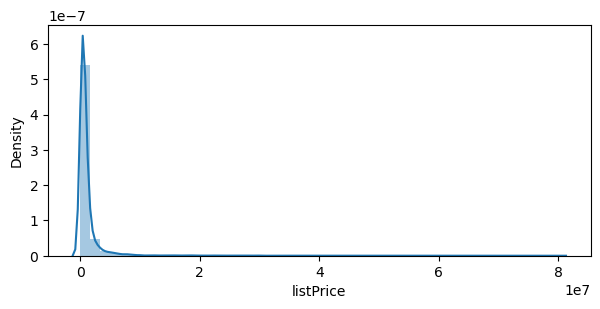

In [22]:
plt.figure(figsize=(7,3))
sns.distplot(cleaned_ds['listPrice'])
plt.show()

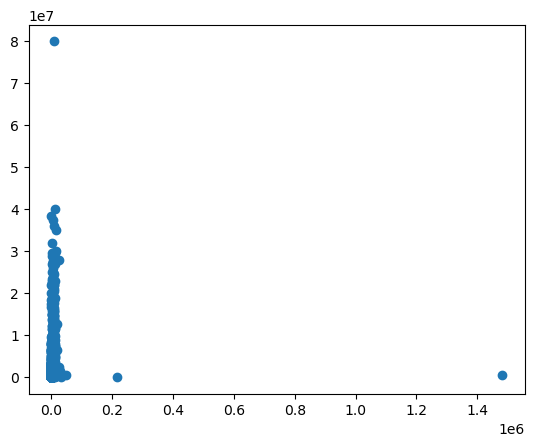

In [23]:
plt.scatter(cleaned_ds['sqft'],cleaned_ds['listPrice'])

In [24]:
log_price = np.log(cleaned_ds['listPrice'])

C:\Users\Eric.Niyitanga\AppData\Local\Temp\ipykernel_20156\1286630314.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(log_price)


<Axes: xlabel='listPrice', ylabel='Density'>

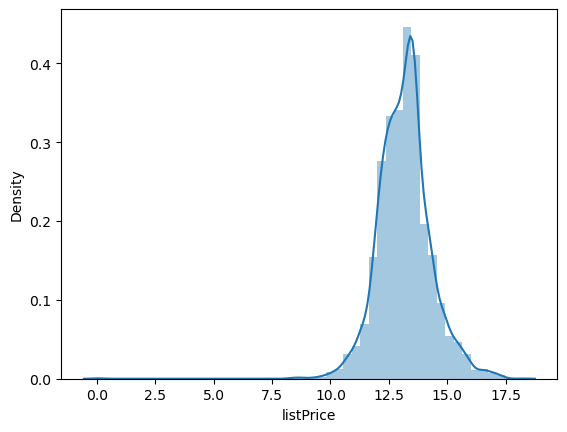

In [25]:
sns.distplot(log_price)

In [26]:
cleaned_ds['log_price'] = np.log(cleaned_ds['listPrice'])

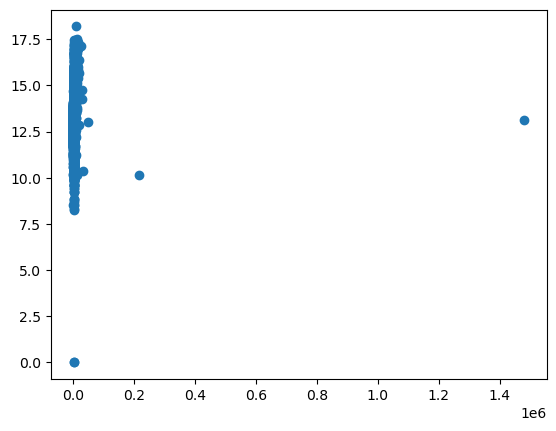

In [27]:
plt.scatter(cleaned_ds['sqft'],cleaned_ds['log_price'])

In [43]:
import pandas as pd
import numpy as np

# Make sure type column is normalized
cleaned_ds["type_norm"] = (
    cleaned_ds["type"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Define groups to match your dataset values
groups = {
    "Single-family": ["single_family"],
    "Multi-family": ["multi_family"],
    "Condos": ["condos", "condo"],
    "Co-ops": ["co_op", "coop"],
    "Townhouses": ["townhouse", "townhome", "townhomes"]
}

summary_rows = []

for label, keys in groups.items():
    mask = cleaned_ds["type_norm"].isin(keys)
    sub = pd.to_numeric(cleaned_ds.loc[mask, "listPrice"], errors="coerce").dropna()

    summary_rows.append({
        "property_type": label,
        "count": len(sub),
        "avg_price": float(sub.mean()) if len(sub) else np.nan,
        "median_price": float(sub.median()) if len(sub) else np.nan
    })

price_summary = pd.DataFrame(summary_rows)
print(price_summary)

   property_type  count     avg_price  median_price
0  Single-family   5090  9.042406e+05      524995.0
1   Multi-family    933  8.349415e+05      603200.0
2         Condos    947  2.184735e+06      750000.0
3         Co-ops    748  1.107633e+06      449000.0
4     Townhouses    171  3.822672e+06      649888.0


In [52]:
cleaned_ds.groupby('type')['listPrice'].aggregate(['mean','median']).round(3)

,mean,median
type,,
apartment,1489666.667,962000.0
condo,651666.667,680000.0
condop,1088800.000,1052500.0
condos,2189607.327,750000.0
coop,1107633.313,449000.0
farm,346321.212,179000.0
land,261898.273,132450.0
multi_family,834941.512,603200.0
single_family,904240.558,524995.0


In [69]:
cleaned_ds['type_norm'] = cleaned_ds['type'].astype(str).str.lower().str.strip()

groups = {'Single-family':['single_family'],
          'Multi-family':['multi_family'],
          'Condos':['condos','condo'],
          'Co-ops':['co_op','coop'],
          'Townhouses':['townhouse','townhome','townhomes']
         }

summary_rows = []

for label, keys in groups.items():
    mask= cleaned_ds['type_norm'].isin(keys)
    sub = pd.to_numeric(cleaned_ds.loc[mask, 'listPrice'],errors="coerce").dropna()
    summary_rows.append({
        "property_type":label,
        "count":len(sub),
        "avg_price": float(sub.mean()) if len(sub) else np.nan,
        "median_price":float(sub.median()) if len(sub) else np.nan
    })
price_summary = pd.DataFrame(summary_rows)
print(price_summary)

   property_type  count     avg_price  median_price
0  Single-family   5090  9.042406e+05      524995.0
1   Multi-family    933  8.349415e+05      603200.0
2         Condos    947  2.184735e+06      750000.0
3         Co-ops    748  1.107633e+06      449000.0
4     Townhouses    171  3.822672e+06      649888.0


C:\Users\Eric.Niyitanga\AppData\Local\Temp\ipykernel_20156\423138898.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sqtr)


<Axes: xlabel='sqft', ylabel='Density'>

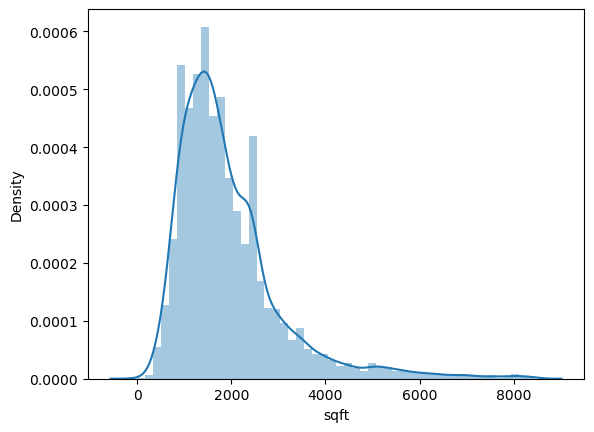

In [74]:
# What is the distribution of square footage?

sqrt = pd.to_numeric(cleaned_ds['sqft'], errors="coerce").dropna()

q = np.quantile(sqrt,0.99)
sqtr = sqrt[sqrt < q]
sns.distplot(sqtr)


=== SQUARE FOOTAGE DISTRIBUTION ===
count    8.137000e+03
mean     2.249162e+03
std      1.664846e+04
min      1.000000e+00
1%       5.000000e+02
5%       7.600000e+02
10%      9.000000e+02
25%      1.200000e+03
50%      1.676000e+03
75%      2.407000e+03
90%      3.370200e+03
95%      4.500000e+03
99%      8.453560e+03
max      1.481040e+06
Name: sqft, dtype: float64


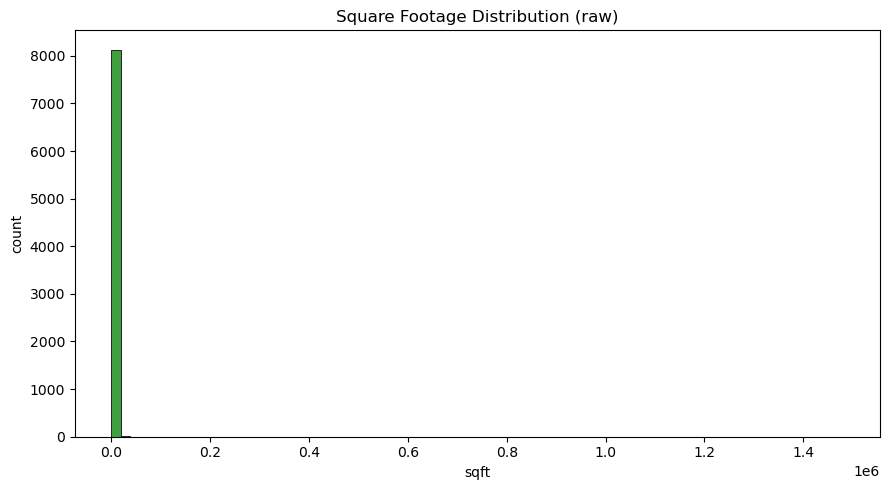

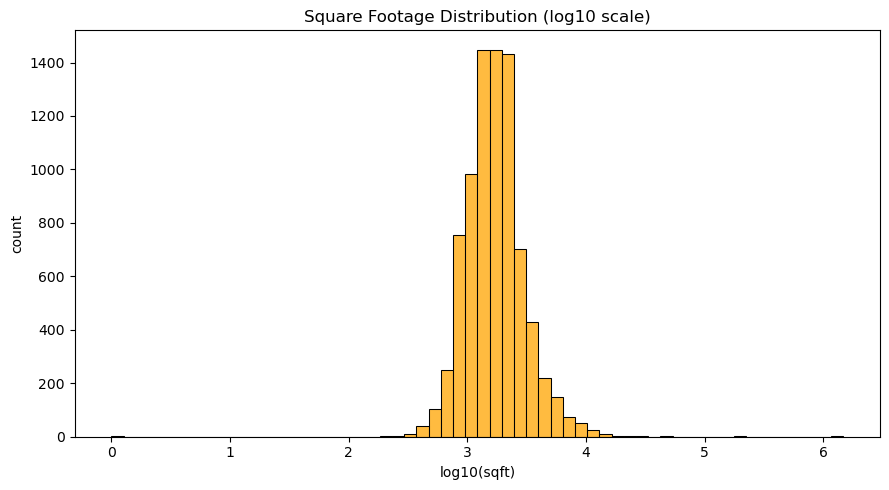

In [78]:

# 1. Summary statistics (distribution numbers)

sqft = pd.to_numeric(cleaned_ds["sqft"], errors="coerce").dropna()

print("\n=== SQUARE FOOTAGE DISTRIBUTION ===")
print(
    sqft.describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

# 2. Histogram (raw)
plt.figure(figsize=(9,5))
sns.histplot(sqft, bins=80, color="green")
plt.title("Square Footage Distribution (raw)")
plt.xlabel("sqft")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 3. Histogram (log-scale)
log_sqft = np.log10(sqft[sqft > 0])
plt.figure(figsize=(9,5))
sns.histplot(log_sqft, bins=60, color="orange")
plt.title("Square Footage Distribution (log10 scale)")
plt.xlabel("log10(sqft)")
plt.ylabel("count")
plt.tight_layout()
plt.show()


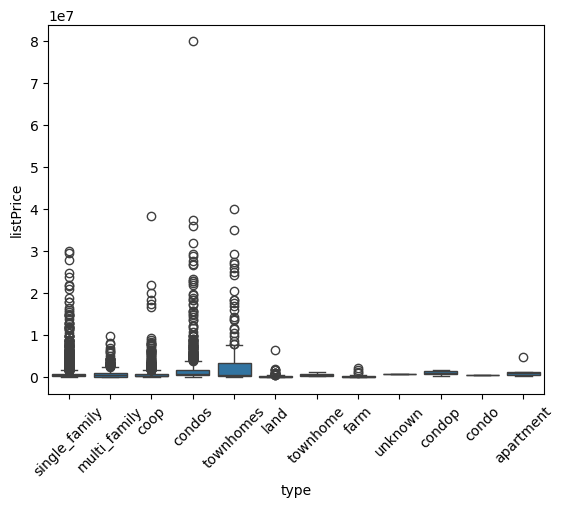

In [86]:
sns.boxplot(x=cleaned_ds['type'],y=cleaned_ds['listPrice'], data=cleaned_ds)
plt.xticks(rotation = 45)
plt.show()

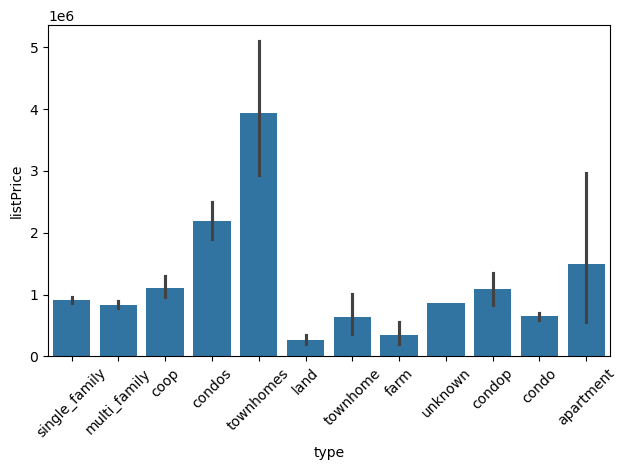

In [87]:
sns.barplot(x=cleaned_ds['type'],y=cleaned_ds['listPrice'], data=cleaned_ds)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [89]:
cleaned_ds['beds'] = pd.to_numeric(cleaned_ds['beds'], errors="coerce")
cleaned_ds['baths'] = pd.to_numeric(cleaned_ds['baths'], errors="coerce")

suspicious_1 = cleaned_ds[cleaned_ds['baths'] > cleaned_ds['beds']]
suspicious_2 = cleaned_ds[cleaned_ds['baths']>6]
suspicious_3 = cleaned_ds[(cleaned_ds['beds'] == 0) & (cleaned_ds['baths']>= 2)]

In [90]:
suspicious_1

,type,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,has_garage,log_price,type_norm
9,condos,299000.0,582.0,18.0,0.0,1.0,1.0,1.0,0.0,0,12.608199,condos
12,condos,279900.0,1211.0,2.0,2.0,3.0,2.0,2.0,2.0,1,12.542188,condos
29,condos,21950000.0,5139.0,2.0,4.0,7.0,6.0,6.0,0.0,0,16.904278,condos
37,single_family,21000000.0,10257.0,2.0,7.0,9.0,5.0,5.0,4.0,1,16.860033,single_family
51,condos,29000000.0,3000.0,2.0,3.0,4.0,3.0,3.0,0.0,0,17.182806,condos
...,...,...,...,...,...,...,...,...,...,...,...,...
8182,multi_family,650000.0,2407.0,2.0,2.0,3.0,3.0,3.0,1.0,1,13.384728,multi_family
8184,condos,560000.0,399.0,4.0,0.0,1.0,1.0,1.0,0.0,0,13.235692,condos
8220,single_family,1350000.0,4202.0,2.0,4.0,5.0,4.0,4.0,3.0,1,14.115615,single_family
8244,single_family,5000000.0,7000.0,2.0,5.0,6.0,4.0,4.0,3.0,1,15.424948,single_family


In [92]:

cleaned_ds["bath_logic_issue"] = (
    (cleaned_ds["baths"] > cleaned_ds["beds"]) |
    (cleaned_ds["baths"] >= 6) |
    ((cleaned_ds["beds"] == 0) & (cleaned_ds["baths"] >= 2))
)


In [95]:
cleaned_ds[cleaned_ds["bath_logic_issue"] == True]

,type,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,has_garage,log_price,type_norm,bath_logic_issue
2,multi_family,799999.0,2407.0,2.0,11.0,6.0,7.0,7.0,1.0,1,13.592366,multi_family,True
8,multi_family,999000.0,5250.0,3.0,12.0,6.0,6.0,6.0,0.0,0,13.814510,multi_family,True
9,condos,299000.0,582.0,18.0,0.0,1.0,1.0,1.0,0.0,0,12.608199,condos,True
12,condos,279900.0,1211.0,2.0,2.0,3.0,2.0,2.0,2.0,1,12.542188,condos,True
29,condos,21950000.0,5139.0,2.0,4.0,7.0,6.0,6.0,0.0,0,16.904278,condos,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8220,single_family,1350000.0,4202.0,2.0,4.0,5.0,4.0,4.0,3.0,1,14.115615,single_family,True
8242,single_family,2249000.0,5000.0,3.0,6.0,6.0,4.0,4.0,2.0,1,14.625996,single_family,True
8243,single_family,3595000.0,4600.0,2.0,6.0,6.0,5.0,5.0,2.0,1,15.095055,single_family,True
8244,single_family,5000000.0,7000.0,2.0,5.0,6.0,4.0,4.0,3.0,1,15.424948,single_family,True


In [96]:
#@@@@ ⦁	Are there rows where the number of bathrooms doesn’t make sense 
#@@@ (e.g., 7 bathrooms with 1 bedroom)?

# Ensure numeric
cleaned_ds["beds"]  = pd.to_numeric(cleaned_ds["beds"], errors="coerce")
cleaned_ds["baths"] = pd.to_numeric(cleaned_ds["baths"], errors="coerce")

# Make a copy (optional, recommended)
corrected_ds = cleaned_ds.copy()

# -----------------------------
# Rule 1: Bathrooms > Bedrooms
# -----------------------------
mask1 = corrected_ds["baths"] > corrected_ds["beds"]

# Fix: set baths to min(beds, baths)
corrected_ds.loc[mask1, "baths"] = corrected_ds.loc[mask1, "beds"]

# -----------------------------
# Rule 2: Bedroom = 0 but Bath > 1
# -----------------------------
mask2 = (corrected_ds["beds"] == 0) & (corrected_ds["baths"] > 1)

# Fix: set baths = 1 (studio-like)
corrected_ds.loc[mask2, "baths"] = 1

# -----------------------------
# Rule 3: Excessively high bathroom counts (e.g., >= 6)
# -----------------------------
mask3 = corrected_ds["baths"] >= 6

# Fix: replace with 4 (high-end max)
corrected_ds.loc[mask3, "baths"] = 4

# -----------------------------
# OPTIONAL: Fill any leftover missing beds/baths
# -----------------------------
corrected_ds["beds"]  = corrected_ds["beds"].fillna(corrected_ds["beds"].median())
corrected_ds["baths"] = corrected_ds["baths"].fillna(corrected_ds["baths"].median())

# Show how many rows were corrected
print("Corrected (baths > beds):", mask1.sum())
print("Corrected (0 beds & many baths):", mask2.sum())
print("Corrected (extreme baths >=6):", mask3.sum())

corrected_ds.head()

Corrected (baths > beds): 799
Corrected (0 beds & many baths): 0
Corrected (extreme baths >=6): 213


,type,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,has_garage,log_price,type_norm,bath_logic_issue
0,single_family,325000.0,1252.0,2.0,3.0,2.0,2.0,2.0,1.0,1,12.691580,single_family,False
1,single_family,308000.0,1758.0,2.0,4.0,4.0,4.0,4.0,0.0,0,12.637855,single_family,False
2,multi_family,799999.0,2407.0,2.0,11.0,4.0,7.0,7.0,1.0,1,13.592366,multi_family,True
3,single_family,189900.0,1400.0,3.0,4.0,2.0,2.0,2.0,2.0,1,12.154253,single_family,False
4,single_family,204900.0,2074.0,2.0,4.0,2.0,2.0,2.0,2.0,1,12.230277,single_family,False


In [98]:
corrected_ds.describe()

,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,has_garage,log_price
count,8.137000e+03,8.137000e+03,8137.000000,8137.000000,8137.000000,8137.000000,8137.000000,8137.000000,8137.000000,8137.000000
mean,1.108110e+06,2.249162e+03,2.773627,3.392589,2.216173,2.086395,2.099422,1.432223,0.498832,13.183571
std,2.561520e+06,1.664846e+04,4.568621,2.061437,1.130320,1.338222,1.341997,21.565993,0.500029,1.129615
min,1.000000e+00,1.000000e+00,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,2.598880e+05,1.200000e+03,2.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,12.468006
50%,5.450000e+05,1.676000e+03,2.000000,3.000000,2.000000,2.000000,2.000000,0.000000,0.000000,13.208541
75%,9.500000e+05,2.407000e+03,2.000000,4.000000,3.000000,2.000000,2.000000,2.000000,1.000000,13.764217
max,8.000000e+07,1.481040e+06,96.000000,100.000000,5.000000,30.000000,30.000000,1440.000000,1.000000,18.197537


In [101]:
# ⦁	How would you standardize the type column (e.g., “condos” vs “condo”)?

corrected_ds["type_norm"] = (
    cleaned_ds["type"]
    .astype(str)
    .str.lower()
    .str.strip()
    .replace({
        "single family": "single_family",
        "single-family": "single_family",
        "singlefamily": "single_family",
        "single_family_home": "single_family",

        "multi family": "multi_family",
        "multi-family": "multi_family",
        "multifamily": "multi_family",
        "multi_family_home": "multi_family",

        "condo": "condo",
        "condos": "condo",
        "condominium": "condo",

        "coop": "co_op",
        "co-op": "co_op",
        "co op": "co_op",

        "townhome": "townhouse",
        "townhomes": "townhouse",
        "town house": "townhouse",
        "townhouse": "townhouse",

        "apartment": "apartment",

        "unknown": "unknown"
    })
)

In [103]:
# ⦁	How would you handle listings where: 
# ⦁	Price = 0?
# ⦁	Beds = 0?
# ⦁	Sqft missing?

corrected_ds['listPrice'] = pd.to_numeric(corrected_ds['listPrice'], errors="coerce")

corrected_ds.loc[corrected_ds['listPrice'] == 0, "listPrice"] = np.nan

corrected_ds['listPrice'] = corrected_ds.groupby('type_norm')['listPrice'].transform(
    lambda x: x.fillna(x.median()))


# Ensure numeric
cleaned_ds["beds"] = pd.to_numeric(cleaned_ds["beds"], errors="coerce")
cleaned_ds["sqft"] = pd.to_numeric(cleaned_ds["sqft"], errors="coerce")

# Step 1: Convert unrealistic 0-beds to NaN (studios kept)
cleaned_ds.loc[
    (cleaned_ds["beds"] == 0) & (cleaned_ds["sqft"] >= 500),
    "beds"
] = np.nan

# Step 2: Fill missing beds using median per property type
cleaned_ds["beds"] = (
    cleaned_ds.groupby("type_norm")["beds"]
              .transform(lambda x: x.fillna(x.median()))
)

cleaned_ds["sqft"] = (
    cleaned_ds.groupby("type_norm")["sqft"]
              .transform(lambda x: x.fillna(x.median()))
)

In [105]:
# ⦁	How would you extract numeric values from text descriptions?



In [106]:
# ⦁	How would you create a new variable called price_per_sqft?

corrected_ds['price_per_sqft'] = corrected_ds['listPrice']/corrected_ds['sqft']

In [109]:

corrected_ds["price_tier"] = pd.cut(
    corrected_ds["listPrice"],
    bins=[0, 300000, 1000000, np.inf],
    labels=["Budget (<300K)", "Mid-range (300K-1M)", "Luxury (>1M)"],
    right=False)

In [110]:
corrected_ds.head()

,type,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,has_garage,log_price,type_norm,bath_logic_issue,price_per_sqft,price_tier
0,single_family,325000.0,1252.0,2.0,3.0,2.0,2.0,2.0,1.0,1,12.691580,single_family,False,259.584665,Mid-range (300K-1M)
1,single_family,308000.0,1758.0,2.0,4.0,4.0,4.0,4.0,0.0,0,12.637855,single_family,False,175.199090,Mid-range (300K-1M)
2,multi_family,799999.0,2407.0,2.0,11.0,4.0,7.0,7.0,1.0,1,13.592366,multi_family,True,332.363523,Mid-range (300K-1M)
3,single_family,189900.0,1400.0,3.0,4.0,2.0,2.0,2.0,2.0,1,12.154253,single_family,False,135.642857,Budget (<300K)
4,single_family,204900.0,2074.0,2.0,4.0,2.0,2.0,2.0,2.0,1,12.230277,single_family,False,98.794600,Budget (<300K)


In [111]:
# ⦁	How would you detect outliers using: 
# ⦁	Z‑scores
# ⦁	IQR method
# ⦁	Isolation Forest

import numpy as np
import pandas as pd

# Choose numeric column
col = "listPrice"

# Convert to numeric
x = pd.to_numeric(cleaned_ds[col], errors="coerce")

# Compute z-scores
z_scores = (x - x.mean()) / x.std()

# Mark outliers
cleaned_ds["zscore_outlier"] = np.where(abs(z_scores) > 3, 1, 0)

# Show outliers
outliers_z = cleaned_ds[cleaned_ds["zscore_outlier"] == 1]
print(outliers_z[[col]])




       listPrice
29    21950000.0
37    21000000.0
51    29000000.0
176   80000000.0
296   26995000.0
...          ...
7947   8900000.0
8102  16450000.0
8126  24995000.0
8165   9995000.0
8254  16000000.0

[117 rows x 1 columns]
